# Website Traffic & Music Engagement Analysis

## Objective
The goal of this project is to analyze user interaction data from a music streaming platform and identify:

- User activity patterns over time  
- Engagement behavior (clicks, previews, pageviews)  
- Most popular content (tracks and artists)  
- Geographic distribution of users  
- Differences in content preferences across countries  

The dataset contains event-level data for one week (August 19–25, 2021).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

## Data Loading Note

The dataset is not included in this repository.

Please download it from Kaggle and place it in the `data/` folder:

https://www.kaggle.com/datasets/bhanupratapbiswas/website-traffic-analysis

## Data Loading

In [ ]:
# Dataset not included in repository
# Download from Kaggle and place in /data folder

traffic_df = pd.read_csv('../data/traffic.csv')

traffic_df.head()

,event,date,country,city,artist,album,track,isrc,linkid
0,click,2021-08-21,Saudi Arabia,Jeddah,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8
1,click,2021-08-21,Saudi Arabia,Jeddah,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8
2,click,2021-08-21,India,Ludhiana,Reyanna Maria,So Pretty,So Pretty,USUM72100871,23199824-9cf5-4b98-942a-34965c3b0cc2
3,click,2021-08-21,France,Unknown,"Simone & Simaria, Sebastian Yatra",No Llores Más,No Llores Más,BRUM72003904,35573248-4e49-47c7-af80-08a960fa74cd
4,click,2021-08-21,Maldives,Malé,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8


## Data Overview

In [3]:
traffic_df.shape

(226278, 9)

In [4]:
traffic_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 226278 entries, 0 to 226277
Data columns (total 9 columns):
 #   Column   Non-Null Count   Dtype 
---  ------   --------------   ----- 
 0   event    226278 non-null  object
 1   date     226278 non-null  object
 2   country  226267 non-null  object
 3   city     226267 non-null  object
 4   artist   226241 non-null  object
 5   album    226273 non-null  object
 6   track    226273 non-null  object
 7   isrc     219157 non-null  object
 8   linkid   226278 non-null  object
dtypes: object(9)
memory usage: 15.5+ MB


In [5]:
traffic_df.columns

Index(['event', 'date', 'country', 'city', 'artist', 'album', 'track', 'isrc',
       'linkid'],
      dtype='object')

In [6]:
traffic_df.isna().sum()

event         0
date          0
country      11
city         11
artist       37
album         5
track         5
isrc       7121
linkid        0
dtype: int64

### Notes
- Dataset contains 226,278 rows and 9 columns  
- Missing values present in some descriptive fields (artist, city, etc.)  
- No missing values in key fields such as `event` and `linkid`

## Data Cleaning

In [7]:
traffic_df.describe()

,event,date,country,city,artist,album,track,isrc,linkid
count,226278,226278,226267,226267,226241,226273,226273,219157,226278
unique,3,7,211,11993,2419,3254,3562,709,3839
top,pageview,2021-08-19,Saudi Arabia,Jeddah,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8
freq,142015,35361,47334,22791,40841,40841,40841,40841,40841


In [8]:
traffic_df.duplicated().sum()

np.int64(103711)

In [9]:
traffic_df[traffic_df.duplicated()].head()

,event,date,country,city,artist,album,track,isrc,linkid
1,click,2021-08-21,Saudi Arabia,Jeddah,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8
62,click,2021-08-23,Saudi Arabia,Jeddah,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8
76,click,2021-08-22,Saudi Arabia,Riyadh,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8
88,click,2021-08-22,Iraq,Erbil,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8
92,click,2021-08-23,India,Ludhiana,Sidhu Moose Wala,Akhian,Akhian,QZQLR2005915,c95f1fc1-fab0-4c74-b3f5-52bd3684a713


In [10]:
traffic_df['event'].value_counts()

event
pageview    142015
click        55732
preview      28531
Name: count, dtype: int64

In [11]:
traffic_df['date'].head()

0    2021-08-21
1    2021-08-21
2    2021-08-21
3    2021-08-21
4    2021-08-21
Name: date, dtype: object

In [12]:
traffic_df['date'].dtype

dtype('O')

In [13]:
traffic_df['date'] = pd.to_datetime(traffic_df['date'])

In [14]:
traffic_df['date'].dtype

dtype('<M8[ns]')

### Notes
- Converted `date` column to datetime format  
- Missing values were retained as they represent real-world data limitations  
- Duplicate rows were not removed, as the dataset represents event logs (each row = user action)

## User Activity Over Time

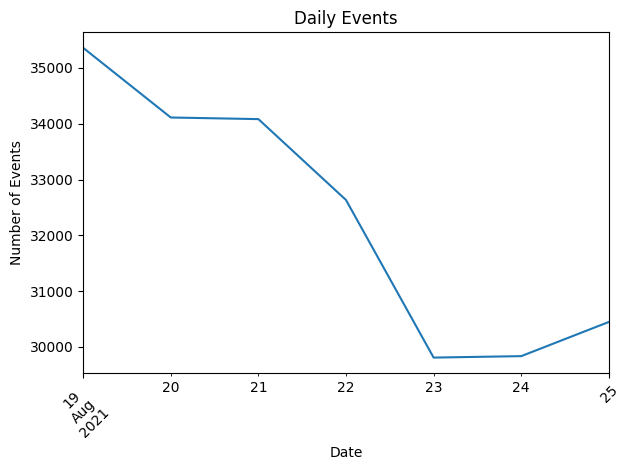

In [15]:
events_per_day = traffic_df.groupby('date').size()

events_per_day.plot()
plt.title("Daily Events")
plt.xlabel("Date")
plt.ylabel("Number of Events")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("images/activity_over_time.png")
plt.show()

### Insight
User activity shows a gradual decline over the observed week, followed by stabilization.

## Event Distribution

In [16]:
event_distribution = (
    traffic_df['event']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .reset_index()
)
event_distribution

,event,proportion
0,pageview,62.76
1,click,24.63
2,preview,12.61


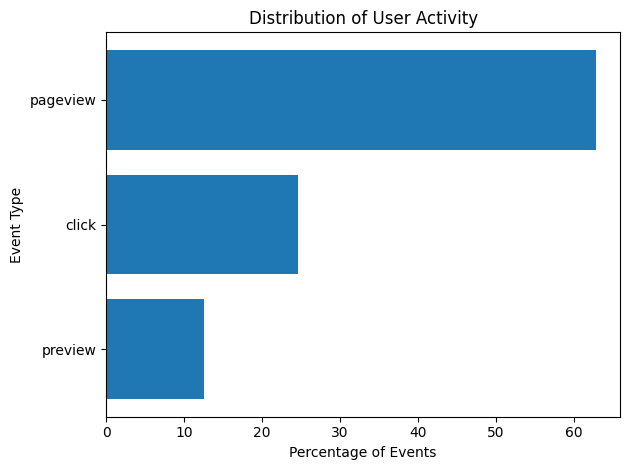

In [17]:
event_distribution.columns = ['event', 'percentage']

plt.barh(event_distribution['event'], event_distribution['percentage'])
plt.title('Distribution of User Activity')
plt.xlabel('Percentage of Events')
plt.ylabel('Event Type')
plt.tight_layout()
plt.gca().invert_yaxis()
plt.savefig("images/event_distribution.png")
plt.show()

### Insight
User activity is dominated by pageviews (~63%), followed by clicks (~25%) and previews (~13%).

## Engagement Metrics

In [18]:
ctr = round(
    (traffic_df['event'] == 'click').sum() /
    (traffic_df['event'] == 'pageview').sum() * 100,
    2
)

preview_rate = round(
    (traffic_df['event'] == 'preview').sum() /
    (traffic_df['event'] == 'pageview').sum() * 100,
    2
)

print(f'Click-Through Rate: {ctr}%,\nPreview Rate: {preview_rate}%')

Click-Through Rate: 39.24%,
Preview Rate: 20.09%


### Insight
- CTR = 39.24% → high engagement level  
- Preview rate = 20.09% → moderate interest in sampling content  

Note: Click-after-preview rate was not used due to non-sequential event structure.

## Most Popular Tracks

In [19]:
clicks = traffic_df[traffic_df['event'] == 'click']
top_tracks = clicks[['track', 'artist']].dropna().value_counts().head(10)
top_tracks

track                                  artist                                                      
Jalebi Baby                            Tesher                                                          9692
Beautiful Day                          Tundra Beats                                                    2198
Beautiful                              Anne-Marie                                                      2172
ily (i love you baby) (feat. Emilee)   Surf Mesa, Emilee                                               1589
Calabria (feat. Lujavo & Nito-Onna)    DMNDS, Strange Fruits Music, Fallen Roses, Lujavo, Nito-Onna    1500
Late At Night                          Roddy Ricch                                                     1364
Summer of Love (Shawn Mendes & Tainy)  Shawn Mendes, Tainy                                             1359
So Pretty                              Reyanna Maria                                                   1187
Candy Shop                          

In [20]:
total_clicks = (traffic_df['event'] == 'click').sum()
top_track_percentage = round((top_tracks.head(1) / total_clicks) * 100, 2)
top_track_percentage

track        artist
Jalebi Baby  Tesher    17.39
Name: count, dtype: float64

### Insight
“Jalebi Baby” by Tesher is the most popular track, accounting for 17.39% of all clicks.

## Geographic Distribution

In [21]:
country_activity = (
    traffic_df['country']
    .fillna('Unknown')
    .value_counts()
    .head(10)
    .reset_index()
)

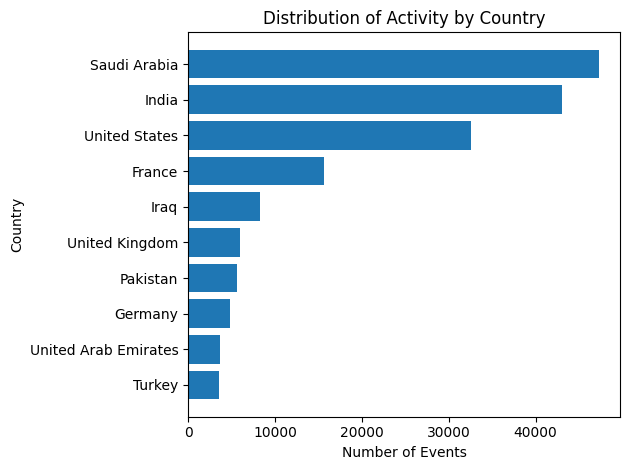

In [22]:
plt.barh(country_activity['country'], country_activity['count'])
plt.title('Distribution of Activity by Country')
plt.xlabel('Number of Events')
plt.ylabel('Country')
plt.tight_layout()
plt.gca().invert_yaxis()
plt.savefig("images/country_activity.png")
plt.show()

In [23]:
top3_share = (
    country_activity['count'].head(3).sum() / len(traffic_df) * 100
).round(2)

top3_share

np.float64(54.31)

### Insight
More than half of all activity (54.31%) comes from the top three countries:
Saudi Arabia, India, and the United States.

## Content Preferences by Country

In [24]:
country_track = (
    clicks
    .groupby(['country', 'track'])
    .size()
    .reset_index(name='clicks')
)

country_track['country_total'] = (
    country_track
    .groupby('country')['clicks']
    .transform('sum')
)

country_track['share_pct'] = (
    country_track['clicks'] / country_track['country_total'] * 100
).round(2)

In [25]:
top_track_per_country = (
    country_track
    .sort_values(['country', 'share_pct'], ascending=[True, False])
    .groupby('country')
    .head(1)
    .reset_index(drop=True)
)

In [26]:
top_track_per_country['track'].value_counts().head()

track
Jalebi Baby                            73
Calabria (feat. Lujavo & Nito-Onna)    11
Beautiful                               8
Beautiful Day                           8
Build a Bitch                           8
Name: count, dtype: int64

In [27]:
# Apply threshold
meaningful = country_track[country_track['country_total'] >= 100]

top_country_tracks = (
    meaningful
    .sort_values(['country', 'share_pct'], ascending=[True, False])
    .groupby('country')
    .head(1)
)
top_country_tracks.head()

,country,track,clicks,country_total,share_pct
58,Algeria,Jalebi Baby,28,129,21.71
144,Australia,Calabria (feat. Lujavo & Nito-Onna),46,628,7.32
285,Austria,Jalebi Baby,97,243,39.92
382,Bahrain,Jalebi Baby,45,196,22.96
443,Bangladesh,Jalebi Baby,100,380,26.32


In [28]:
top_country_tracks['track'].value_counts().head()

track
Jalebi Baby                            31
Calabria (feat. Lujavo & Nito-Onna)     4
Late At Night                           3
TODO O NADA                             1
Ramen OJ                                1
Name: count, dtype: int64

### Insight
After excluding low-activity countries, results show:

- Strong global dominance of certain tracks  
- While “Jalebi Baby” appears to dominate in 73 countries overall, this number drops to 31 after excluding low-activity countries, indicating that part of its dominance is driven by small-sample effects. However, it remains the leading track even among high-activity regions.
- Indicates global convergence in music preferences

## Conclusion

The analysis reveals:

- Strong user engagement with high click-through rate  
- Activity concentrated in a small number of countries  
- Clear dominance of specific global tracks  
- Limited evidence of strong regional variation in preferences  

Overall, the dataset reflects a highly engaged audience with globally aligned content consumption patterns.